# Heart Failure Prediction: FT-Transformer + 1D CNN Ensemble (Improved)

This notebook applies the **FT-Transformer + 1D CNN Ensemble** model to the **Heart Failure Clinical Records** dataset.

## Key Improvements over v1
1. **Class-weighted loss** (pos_weight) to handle imbalanced classes
2. **Feature engineering** — log-transform for heavily skewed features
3. **80/10/10 split** — more training data from this small dataset
4. **Larger FT-Transformer** (d_model=64, n_layers=3)
5. **ReduceLROnPlateau** scheduler for adaptive learning-rate decay
6. **Extended training** (300 epochs, patience=40)

## 1. Imports & Setup

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, recall_score
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')

Device: cpu
PyTorch: 2.11.0+cpu


## 2. Data Loading & Exploration

In [20]:
df = pd.read_csv('heart_failure_clinical_records_dataset.csv')

print(f'Dataset shape: {df.shape}')
print(f'\nTarget distribution:\n{df["DEATH_EVENT"].value_counts()}')
print(f'\nClass ratio (neg/pos): {(df["DEATH_EVENT"]==0).sum() / (df["DEATH_EVENT"]==1).sum():.2f}')

Dataset shape: (299, 13)

Target distribution:
DEATH_EVENT
0    203
1     96
Name: count, dtype: int64

Class ratio (neg/pos): 2.11


## 3. Data Preprocessing

### Key changes
- **Log-transform** heavily skewed numerical features (`creatinine_phosphokinase`, `platelets`, `serum_creatinine`)
- **80 / 10 / 10 split** to maximise training data on this tiny dataset
- **Class-weighted loss** computed from training-set class counts

In [21]:
# Define feature types
categorical_cols = ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking']
numerical_cols = ['age', 'creatinine_phosphokinase', 'ejection_fraction',
                  'platelets', 'serum_creatinine', 'serum_sodium', 'time']
target_col = 'DEATH_EVENT'
all_feature_cols = numerical_cols + categorical_cols

X = df[all_feature_cols].copy()
y = df[target_col].values

# --- Feature engineering: log-transform heavily skewed features ---
skewed_cols = ['creatinine_phosphokinase', 'platelets', 'serum_creatinine']
for col in skewed_cols:
    X[col] = np.log1p(X[col])
print('Log-transformed skewed features:', skewed_cols)

# Compute cardinalities for categorical embeddings
cardinalities = [int(X[c].nunique()) for c in categorical_cols]
n_numerical = len(numerical_cols)
n_features = len(all_feature_cols)

print(f'Numerical features ({n_numerical}): {numerical_cols}')
print(f'Categorical features ({len(categorical_cols)}): {categorical_cols}')
print(f'Total features: {n_features}')
print(f'Target distribution: 0={sum(y==0)}, 1={sum(y==1)}')

Log-transformed skewed features: ['creatinine_phosphokinase', 'platelets', 'serum_creatinine']
Numerical features (7): ['age', 'creatinine_phosphokinase', 'ejection_fraction', 'platelets', 'serum_creatinine', 'serum_sodium', 'time']
Categorical features (5): ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking']
Total features: 12
Target distribution: 0=203, 1=96


In [22]:
# Train / Validation / Test split  — 80 / 10 / 10 (stratified)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)

print(f'Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}')
print(f'Train target dist: 0={sum(y_train==0)}, 1={sum(y_train==1)}')

# --- Class-weighted loss ---
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
pos_weight_val = n_neg / n_pos
pos_weight_tensor = torch.tensor([pos_weight_val], dtype=torch.float32).to(device)
print(f'pos_weight for BCEWithLogitsLoss: {pos_weight_val:.2f}')

# Scale numerical features (fit on train only)
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_val[numerical_cols] = scaler.transform(X_val[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

Train: 239 | Val: 30 | Test: 30
Train target dist: 0=162, 1=77
pos_weight for BCEWithLogitsLoss: 2.10


In [23]:
# Prepare tensors for FT-Transformer (separate num/cat)
def to_ft_tensors(X_df, y_arr):
    X_num = torch.tensor(X_df[numerical_cols].values, dtype=torch.float32)
    X_cat = torch.tensor(X_df[categorical_cols].values, dtype=torch.long)
    y_t = torch.tensor(y_arr, dtype=torch.float32)
    return X_num, X_cat, y_t

# Prepare tensors for 1D CNN (all features, scaled)
cnn_scaler = StandardScaler()
X_train_cnn = cnn_scaler.fit_transform(X_train[all_feature_cols].values)
X_val_cnn = cnn_scaler.transform(X_val[all_feature_cols].values)
X_test_cnn = cnn_scaler.transform(X_test[all_feature_cols].values)

# FT-Transformer tensors
X_num_train, X_cat_train, y_train_t = to_ft_tensors(X_train, y_train)
X_num_val, X_cat_val, y_val_t = to_ft_tensors(X_val, y_val)
X_num_test, X_cat_test, y_test_t = to_ft_tensors(X_test, y_test)

# CNN tensors — shape: (batch, 1, n_features)
X_cnn_train = torch.tensor(X_train_cnn, dtype=torch.float32).unsqueeze(1)
X_cnn_val = torch.tensor(X_val_cnn, dtype=torch.float32).unsqueeze(1)
X_cnn_test = torch.tensor(X_test_cnn, dtype=torch.float32).unsqueeze(1)

print(f'FT-Transformer tensors — Num: {X_num_train.shape}, Cat: {X_cat_train.shape}')
print(f'CNN tensors — {X_cnn_train.shape}')

FT-Transformer tensors — Num: torch.Size([239, 7]), Cat: torch.Size([239, 5])
CNN tensors — torch.Size([239, 1, 12])


## 4. Model Architectures

In [24]:
class NumericalEmbedding(nn.Module):
    def __init__(self, n_numerical, d_model):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(n_numerical, d_model))
        self.biases = nn.Parameter(torch.zeros(n_numerical, d_model))
        nn.init.xavier_uniform_(self.weights)

    def forward(self, x):
        return x.unsqueeze(-1) * self.weights.unsqueeze(0) + self.biases.unsqueeze(0)


class CategoricalEmbedding(nn.Module):
    def __init__(self, cardinalities, d_model):
        super().__init__()
        self.embeddings = nn.ModuleList([
            nn.Embedding(card, d_model) for card in cardinalities
        ])

    def forward(self, x):
        out = [emb(x[:, i]) for i, emb in enumerate(self.embeddings)]
        return torch.stack(out, dim=1)


class FTTransformer(nn.Module):
    def __init__(self, n_numerical, cardinalities, d_model=64, n_heads=4,
                 n_layers=3, d_ff_factor=2, dropout=0.2):
        super().__init__()
        self.num_embedding = NumericalEmbedding(n_numerical, d_model)
        self.cat_embedding = CategoricalEmbedding(cardinalities, d_model)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))
        nn.init.xavier_uniform_(self.cls_token)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model * d_ff_factor,
            dropout=dropout, activation='gelu',
            batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.layer_norm = nn.LayerNorm(d_model)
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(d_model, 1)
        )

    def forward(self, x_num, x_cat):
        B = x_num.size(0)
        num_tokens = self.num_embedding(x_num)
        cat_tokens = self.cat_embedding(x_cat)
        cls = self.cls_token.expand(B, -1, -1)
        tokens = torch.cat([cls, num_tokens, cat_tokens], dim=1)
        out = self.transformer(tokens)
        cls_out = self.layer_norm(out[:, 0])
        return self.head(cls_out).squeeze(-1)


class CNN1D(nn.Module):
    def __init__(self, n_features, dropout=0.3):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.GELU(), nn.Dropout(dropout)
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(dropout)
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(dropout)
        )
        self.classifier = nn.Sequential(
            nn.Linear(256, 128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, 64), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = x.mean(dim=2)
        return self.classifier(x).squeeze(-1)


# --- Configs ---
FT_CONFIG = {
    'd_model': 64, 'n_heads': 4, 'n_layers': 3,
    'dropout': 0.2, 'lr': 5e-4, 'wd': 1e-4, 'batch_size': 32
}

CNN_CONFIG = {
    'dropout': 0.3, 'lr': 5e-4, 'wd': 1e-4, 'batch_size': 32
}

print('FT-Transformer config:', FT_CONFIG)
print('CNN config:', CNN_CONFIG)

FT-Transformer config: {'d_model': 64, 'n_heads': 4, 'n_layers': 3, 'dropout': 0.2, 'lr': 0.0005, 'wd': 0.0001, 'batch_size': 32}
CNN config: {'dropout': 0.3, 'lr': 0.0005, 'wd': 0.0001, 'batch_size': 32}


## 5. Training Utilities (with class-weighted loss)

In [25]:
# Weighted BCE loss
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
print(f'Using BCEWithLogitsLoss with pos_weight={pos_weight_val:.2f}')

# ===== FT-Transformer training =====
def train_ft_epoch(model, X_num, X_cat, y, optimizer, criterion, batch_size):
    model.train()
    loader = DataLoader(TensorDataset(X_num, X_cat, y), batch_size=batch_size, shuffle=True)
    total_loss, correct, total = 0, 0, 0
    for xn, xc, yb in loader:
        xn, xc, yb = xn.to(device), xc.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xn, xc)
        loss = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * yb.size(0)
        correct += ((torch.sigmoid(logits) >= 0.5).float() == yb).sum().item()
        total += yb.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_ft(model, X_num, X_cat, y, criterion):
    model.eval()
    loader = DataLoader(TensorDataset(X_num, X_cat, y), batch_size=256, shuffle=False)
    total_loss, all_probs, total = 0, [], 0
    for xn, xc, yb in loader:
        xn, xc, yb = xn.to(device), xc.to(device), yb.to(device)
        logits = model(xn, xc)
        total_loss += criterion(logits, yb).item() * yb.size(0)
        all_probs.append(torch.sigmoid(logits).cpu())
        total += yb.size(0)
    probs = torch.cat(all_probs).numpy()
    preds = (probs >= 0.5).astype(float)
    acc = accuracy_score(y.numpy(), preds)
    return total_loss / total, acc, preds, probs


# ===== CNN training =====
def train_cnn_epoch(model, X, y, optimizer, criterion, batch_size):
    model.train()
    loader = DataLoader(TensorDataset(X, y), batch_size=batch_size, shuffle=True)
    total_loss, correct, total = 0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * yb.size(0)
        correct += ((torch.sigmoid(logits) >= 0.5).float() == yb).sum().item()
        total += yb.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_cnn(model, X, y, criterion):
    model.eval()
    loader = DataLoader(TensorDataset(X, y), batch_size=256, shuffle=False)
    total_loss, all_probs, total = 0, [], 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        total_loss += criterion(logits, yb).item() * yb.size(0)
        all_probs.append(torch.sigmoid(logits).cpu())
        total += yb.size(0)
    probs = torch.cat(all_probs).numpy()
    preds = (probs >= 0.5).astype(float)
    acc = accuracy_score(y.numpy(), preds)
    return total_loss / total, acc, preds, probs

print('Training utilities defined (with class-weighted loss).')

Using BCEWithLogitsLoss with pos_weight=2.10
Training utilities defined (with class-weighted loss).


## 6. Train FT-Transformer

In [27]:
EPOCHS = 300
PATIENCE = 40

torch.manual_seed(SEED)
np.random.seed(SEED)

ft_model = FTTransformer(
    n_numerical=n_numerical, cardinalities=cardinalities,
    d_model=FT_CONFIG['d_model'], n_heads=FT_CONFIG['n_heads'],
    n_layers=FT_CONFIG['n_layers'], dropout=FT_CONFIG['dropout']
).to(device)

ft_optimizer = optim.AdamW(ft_model.parameters(), lr=FT_CONFIG['lr'], weight_decay=FT_CONFIG['wd'])
ft_scheduler = optim.lr_scheduler.ReduceLROnPlateau(ft_optimizer, mode='max', factor=0.5, patience=10)

ft_history = {'train_acc': [], 'val_acc': []}
best_ft_acc = 0
best_ft_state = None
patience_ctr = 0

print(f'Training FT-Transformer (epochs={EPOCHS}, patience={PATIENCE})...')
print('-' * 60)

for epoch in range(EPOCHS):
    tr_loss, tr_acc = train_ft_epoch(
        ft_model, X_num_train, X_cat_train, y_train_t,
        ft_optimizer, criterion, FT_CONFIG['batch_size']
    )
    val_loss, val_acc, _, _ = eval_ft(
        ft_model, X_num_val, X_cat_val, y_val_t, criterion
    )
    ft_scheduler.step(val_acc)
    ft_history['train_acc'].append(tr_acc)
    ft_history['val_acc'].append(val_acc)

    if val_acc > best_ft_acc:
        best_ft_acc = val_acc
        best_ft_state = {k: v.clone() for k, v in ft_model.state_dict().items()}
        patience_ctr = 0
    else:
        patience_ctr += 1

    if (epoch + 1) % 30 == 0 or patience_ctr == 0:
        print(f'Epoch {epoch+1:3d} | Train: {tr_acc:.4f} | Val: {val_acc:.4f} {"*" if patience_ctr==0 else ""}')

    if patience_ctr >= PATIENCE:
        print(f'Early stopping at epoch {epoch+1}')
        break

ft_model.load_state_dict(best_ft_state)
print(f'\nBest FT-Transformer Val Accuracy: {best_ft_acc:.4f}')

Training FT-Transformer (epochs=300, patience=40)...
------------------------------------------------------------
Epoch   1 | Train: 0.6360 | Val: 0.6000 *
Epoch   2 | Train: 0.7029 | Val: 0.6667 *
Epoch   9 | Train: 0.8075 | Val: 0.7000 *
Epoch  14 | Train: 0.8577 | Val: 0.7333 *
Epoch  22 | Train: 0.9121 | Val: 0.7667 *
Epoch  30 | Train: 0.9205 | Val: 0.7000 
Epoch  60 | Train: 0.9749 | Val: 0.6667 
Early stopping at epoch 62

Best FT-Transformer Val Accuracy: 0.7667


## 7. Train 1D CNN

In [29]:
torch.manual_seed(SEED)
np.random.seed(SEED)

cnn_model = CNN1D(n_features=n_features, dropout=CNN_CONFIG['dropout']).to(device)

cnn_optimizer = optim.AdamW(cnn_model.parameters(), lr=CNN_CONFIG['lr'], weight_decay=CNN_CONFIG['wd'])
cnn_scheduler = optim.lr_scheduler.ReduceLROnPlateau(cnn_optimizer, mode='max', factor=0.5, patience=10)

cnn_history = {'train_acc': [], 'val_acc': []}
best_cnn_acc = 0
best_cnn_state = None
patience_ctr = 0

print(f'Training 1D CNN (epochs={EPOCHS}, patience={PATIENCE})...')
print('-' * 60)

for epoch in range(EPOCHS):
    tr_loss, tr_acc = train_cnn_epoch(
        cnn_model, X_cnn_train, y_train_t,
        cnn_optimizer, criterion, CNN_CONFIG['batch_size']
    )
    val_loss, val_acc, _, _ = eval_cnn(
        cnn_model, X_cnn_val, y_val_t, criterion
    )
    cnn_scheduler.step(val_acc)
    cnn_history['train_acc'].append(tr_acc)
    cnn_history['val_acc'].append(val_acc)

    if val_acc > best_cnn_acc:
        best_cnn_acc = val_acc
        best_cnn_state = {k: v.clone() for k, v in cnn_model.state_dict().items()}
        patience_ctr = 0
    else:
        patience_ctr += 1

    if (epoch + 1) % 30 == 0 or patience_ctr == 0:
        print(f'Epoch {epoch+1:3d} | Train: {tr_acc:.4f} | Val: {val_acc:.4f} {"*" if patience_ctr==0 else ""}')

    if patience_ctr >= PATIENCE:
        print(f'Early stopping at epoch {epoch+1}')
        break

cnn_model.load_state_dict(best_cnn_state)
print(f'\nBest 1D CNN Val Accuracy: {best_cnn_acc:.4f}')

Training 1D CNN (epochs=300, patience=40)...
------------------------------------------------------------
Epoch   1 | Train: 0.6904 | Val: 0.6667 *
Epoch   2 | Train: 0.5690 | Val: 0.7333 *
Epoch  30 | Train: 0.7322 | Val: 0.7000 
Early stopping at epoch 42

Best 1D CNN Val Accuracy: 0.7333


## 8. Training Curves

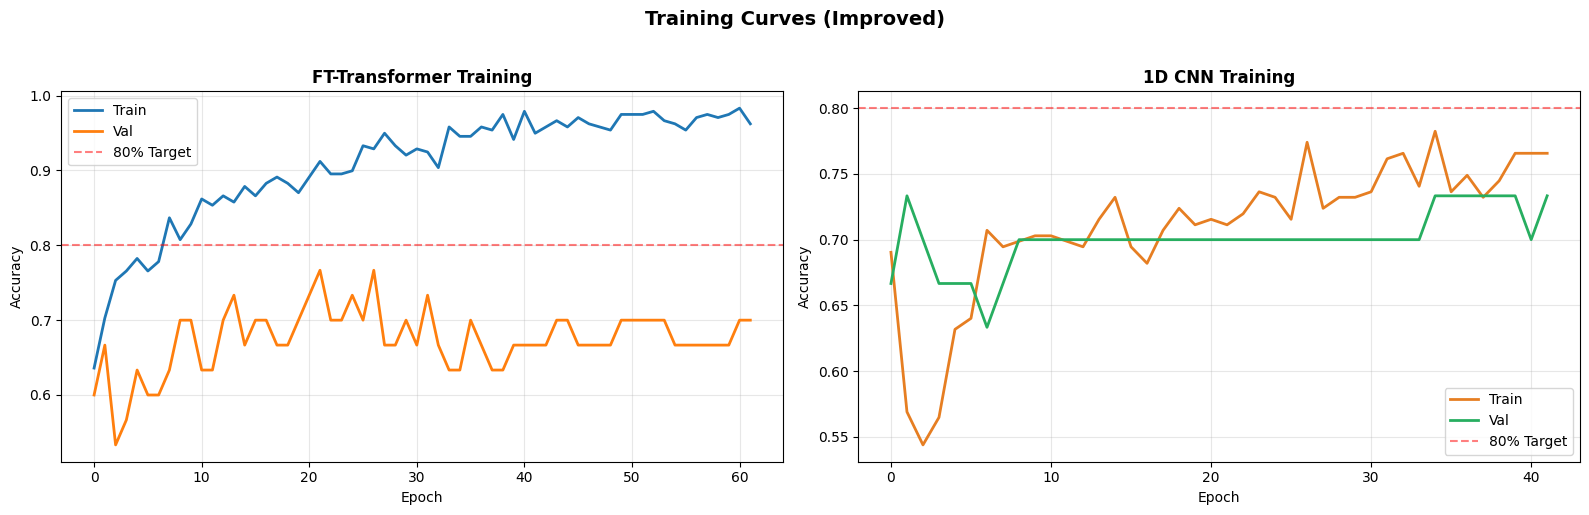

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(ft_history['train_acc'], label='Train', linewidth=2)
axes[0].plot(ft_history['val_acc'], label='Val', linewidth=2)
axes[0].axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='80% Target')
axes[0].set_title('FT-Transformer Training', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(cnn_history['train_acc'], label='Train', linewidth=2, color='#e67e22')
axes[1].plot(cnn_history['val_acc'], label='Val', linewidth=2, color='#27ae60')
axes[1].axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='80% Target')
axes[1].set_title('1D CNN Training', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Training Curves (Improved)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9. Ensemble — Soft Voting

In [31]:
# Get predictions from both models
_, ft_val_acc, ft_val_preds, ft_val_probs = eval_ft(ft_model, X_num_val, X_cat_val, y_val_t, criterion)
_, ft_test_acc, ft_test_preds, ft_test_probs = eval_ft(ft_model, X_num_test, X_cat_test, y_test_t, criterion)

_, cnn_val_acc, cnn_val_preds, cnn_val_probs = eval_cnn(cnn_model, X_cnn_val, y_val_t, criterion)
_, cnn_test_acc, cnn_test_preds, cnn_test_probs = eval_cnn(cnn_model, X_cnn_test, y_test_t, criterion)

print('Individual Model Results:')
print(f'  FT-Transformer — Val: {ft_val_acc:.4f} | Test: {ft_test_acc:.4f}')
print(f'  1D CNN         — Val: {cnn_val_acc:.4f} | Test: {cnn_test_acc:.4f}')

Individual Model Results:
  FT-Transformer — Val: 0.7667 | Test: 0.9000
  1D CNN         — Val: 0.7333 | Test: 0.7000


Searching for optimal ensemble weight...
------------------------------------------------------------


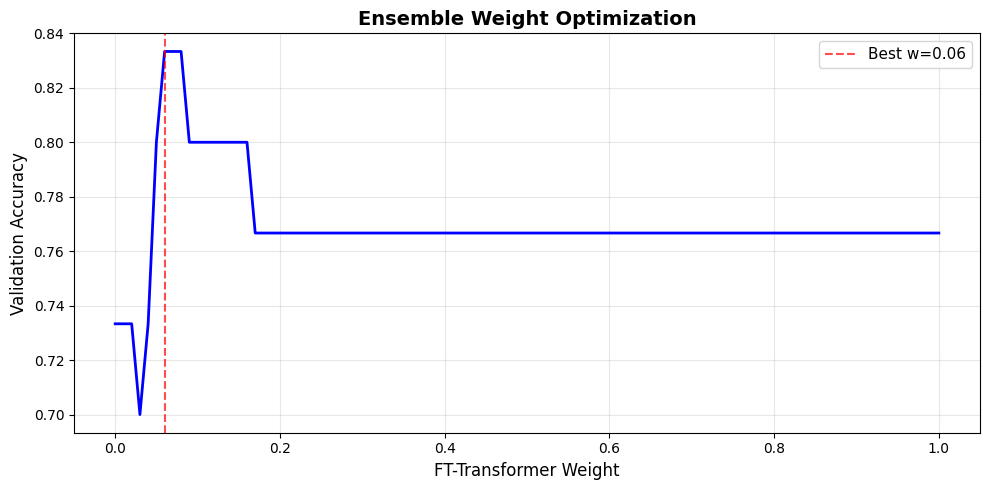


Optimal weight: w_FT=0.06, w_CNN=0.94
Best Ensemble Val Accuracy: 0.8333


In [32]:
print('Searching for optimal ensemble weight...')
print('-' * 60)

best_w, best_ens_val_acc = 0.5, 0
weight_results = []

for w in np.arange(0.0, 1.01, 0.01):
    ens_probs = w * ft_val_probs + (1 - w) * cnn_val_probs
    ens_preds = (ens_probs >= 0.5).astype(float)
    acc = accuracy_score(y_val, ens_preds)
    weight_results.append({'weight_ft': w, 'val_acc': acc})
    if acc > best_ens_val_acc:
        best_ens_val_acc = acc
        best_w = w

weight_df = pd.DataFrame(weight_results)

plt.figure(figsize=(10, 5))
plt.plot(weight_df['weight_ft'], weight_df['val_acc'], 'b-', linewidth=2)
plt.axvline(x=best_w, color='red', linestyle='--', alpha=0.7, label=f'Best w={best_w:.2f}')
plt.xlabel('FT-Transformer Weight', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.title('Ensemble Weight Optimization', fontsize=14, fontweight='bold')
plt.legend(fontsize=11); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f'\nOptimal weight: w_FT={best_w:.2f}, w_CNN={1-best_w:.2f}')
print(f'Best Ensemble Val Accuracy: {best_ens_val_acc:.4f}')

## 10. Final Test Set Evaluation

In [33]:
# Apply optimal weight to test set
ens_test_probs = best_w * ft_test_probs + (1 - best_w) * cnn_test_probs
ens_test_preds = (ens_test_probs >= 0.5).astype(float)

ens_test_acc = accuracy_score(y_test, ens_test_preds)
ens_test_f1 = f1_score(y_test, ens_test_preds)
ens_test_auc = roc_auc_score(y_test, ens_test_probs)
ens_test_recall = recall_score(y_test, ens_test_preds)

ft_test_f1 = f1_score(y_test, ft_test_preds)
ft_test_auc = roc_auc_score(y_test, ft_test_probs)
ft_test_recall = recall_score(y_test, ft_test_preds)

cnn_test_f1 = f1_score(y_test, cnn_test_preds)
cnn_test_auc = roc_auc_score(y_test, cnn_test_probs)
cnn_test_recall = recall_score(y_test, cnn_test_preds)

print('=' * 80)
print('TEST SET RESULTS (Heart Failure Dataset — Improved)')
print('=' * 80)
print(f'{"Model":<25} {"Accuracy":>10} {"F1":>10} {"Recall":>10} {"AUC-ROC":>10}')
print('-' * 80)
print(f'{"FT-Transformer":<25} {ft_test_acc:>10.4f} {ft_test_f1:>10.4f} {ft_test_recall:>10.4f} {ft_test_auc:>10.4f}')
print(f'{"1D CNN":<25} {cnn_test_acc:>10.4f} {cnn_test_f1:>10.4f} {cnn_test_recall:>10.4f} {cnn_test_auc:>10.4f}')
print('-' * 80)
w_str = f'Ensemble (w={best_w:.2f})'
print(f'{w_str:<25} {ens_test_acc:>10.4f} {ens_test_f1:>10.4f} {ens_test_recall:>10.4f} {ens_test_auc:>10.4f}')
print('=' * 80)

TEST SET RESULTS (Heart Failure Dataset — Improved)
Model                       Accuracy         F1     Recall    AUC-ROC
--------------------------------------------------------------------------------
FT-Transformer                0.9000     0.8235     0.7778     0.9524
1D CNN                        0.7000     0.1818     0.1111     0.6190
--------------------------------------------------------------------------------
Ensemble (w=0.06)             0.8667     0.7143     0.5556     0.8836


In [34]:
print('Ensemble Classification Report:')
print('=' * 60)
print(classification_report(y_test, ens_test_preds,
                            target_names=['Survived', 'Died']))

Ensemble Classification Report:
              precision    recall  f1-score   support

    Survived       0.84      1.00      0.91        21
        Died       1.00      0.56      0.71         9

    accuracy                           0.87        30
   macro avg       0.92      0.78      0.81        30
weighted avg       0.89      0.87      0.85        30



In [ ]:
# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
models_data = [
    ('FT-Transformer', ft_test_preds, ft_test_acc),
    ('1D CNN', cnn_test_preds, cnn_test_acc),
    ('Ensemble', ens_test_preds, ens_test_acc),
]
for ax, (name, preds, acc) in zip(axes, models_data):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True,
                xticklabels=['Survived', 'Died'],
                yticklabels=['Survived', 'Died'],
                annot_kws={'size': 14}, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'{name}\nAccuracy: {acc*100:.2f}%', fontweight='bold')
plt.suptitle('Confusion Matrices — Improved', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

In [ ]:
# ROC Curves
plt.figure(figsize=(9, 7))
for name, probs, color in [
    ('FT-Transformer', ft_test_probs, '#3498db'),
    ('1D CNN', cnn_test_probs, '#e67e22'),
    ('Ensemble', ens_test_probs, '#e74c3c'),
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, linewidth=2.5, color=color, label=f'{name} (AUC={auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — Improved', fontsize=14, fontweight='bold')
plt.legend(fontsize=11); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()